<a href="https://colab.research.google.com/github/pavansh07/NIT_RAIPUR/blob/main/Node_Embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**For implementing I took CORA dataset which have 7 classes total**

| class | Topic                  |
| ----- | ---------------------- |
| 0     | Case Based             |
| 1     | Genetic Algorithms     |
| 2     | Neural Networks        |
| 3     | Probabilistic Methods  |
| 4     | Reinforcement Learning |
| 5     | Rule Learning          |
| 6     | Theory                 |


In [ ]:
!pip install torch-geometric
!pip install scikit-learn

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv

In [ ]:
dataset = Planetoid(
    root='data/Cora',
    name='Cora'
)

data = dataset[0]

In [ ]:
print(data)

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])


**CASE 1 — NOT USING GNN**

In [ ]:
class MLP(nn.Module):

    def __init__(self):

        super().__init__()

        self.lin1 = nn.Linear(
            dataset.num_features,
            16
        )

        self.lin2 = nn.Linear(
            16,
            dataset.num_classes
        )

    def forward(self, x):

        x = self.lin1(x)

        x = F.relu(x)

        embedding = x

        x = self.lin2(x)

        return x, embedding

In [ ]:
mlp = MLP()

optimizer = torch.optim.Adam(
    mlp.parameters(),
    lr=0.01
)

for epoch in range(200):

    mlp.train()

    optimizer.zero_grad()

    out, emb = mlp(data.x)

    loss = F.cross_entropy(
        out[data.train_mask],
        data.y[data.train_mask]
    )

    loss.backward()

    optimizer.step()

In [ ]:
mlp.eval()

out, mlp_embeddings = mlp(data.x)

pred = out.argmax(dim=1)

correct = (
    pred[data.test_mask]
    ==
    data.y[data.test_mask]
).sum()

acc = int(correct) / int(data.test_mask.sum())

print("MLP Accuracy:", acc)

MLP Accuracy: 0.453


**CASE 2 — GNN WITHOUT LEARNED EMBEDDINGS**

In [ ]:
x = data.x

edge_index = data.edge_index

source = edge_index[0]
target = edge_index[1]

aggregated = torch.zeros_like(x)

aggregated.index_add_(0, target, x[source])

degree = torch.bincount(
    target,
    minlength=x.size(0)
).unsqueeze(1)

aggregated = aggregated / degree.clamp(min=1)

In [ ]:
classifier = nn.Linear(
    dataset.num_features,
    dataset.num_classes
)

optimizer = torch.optim.Adam(
    classifier.parameters(),
    lr=0.01
)

In [ ]:
for epoch in range(200):

    optimizer.zero_grad()

    out = classifier(aggregated)

    loss = F.cross_entropy(
        out[data.train_mask],
        data.y[data.train_mask]
    )

    loss.backward()

    optimizer.step()

In [ ]:
pred = out.argmax(dim=1)

correct = (
    pred[data.test_mask]
    ==
    data.y[data.test_mask]
).sum()

acc = int(correct) / int(data.test_mask.sum())

print("Propagation Accuracy:", acc)

Propagation Accuracy: 0.72


**CASE 3 — GNN WITH LEARNED EMBEDDINGS**

In [ ]:
class GCN(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1 = GCNConv(
            dataset.num_features,
            16
        )

        self.conv2 = GCNConv(
            16,
            dataset.num_classes
        )

    def forward(self, x, edge_index):

        x = self.conv1(x, edge_index)

        embedding = x

        x = F.relu(x)

        x = self.conv2(x, edge_index)

        return x, embedding

In [ ]:
gcn = GCN()

optimizer = torch.optim.Adam(
    gcn.parameters(),
    lr=0.01
)

for epoch in range(200):

    gcn.train()

    optimizer.zero_grad()

    out, emb = gcn(
        data.x,
        data.edge_index
    )

    loss = F.cross_entropy(
        out[data.train_mask],
        data.y[data.train_mask]
    )

    loss.backward()

    optimizer.step()

In [ ]:
gcn.eval()

out, gcn_embeddings = gcn(
    data.x,
    data.edge_index
)

pred = out.argmax(dim=1)

correct = (
    pred[data.test_mask]
    ==
    data.y[data.test_mask]
).sum()

acc = int(correct) / int(data.test_mask.sum())

print("GCN Accuracy:", acc)

GCN Accuracy: 0.791


**VISUALIZATION USING MATPLOTLIB**

In [ ]:
def plot_embeddings_separate(embeddings, title):

    pca = PCA(n_components=2)

    emb_2d = pca.fit_transform(
        embeddings.detach().numpy()
    )

    labels = data.y.numpy()

    plt.figure(figsize=(10,10))

    unique_labels = set(labels)

    for label in unique_labels:

        idx = labels == label

        plt.scatter(
            emb_2d[idx, 0],
            emb_2d[idx, 1],
            label=f'Class {label}',
            s=20
        )

    plt.legend()

    plt.title(title)

    plt.xlabel("PCA Dimension 1")

    plt.ylabel("PCA Dimension 2")

    plt.show()

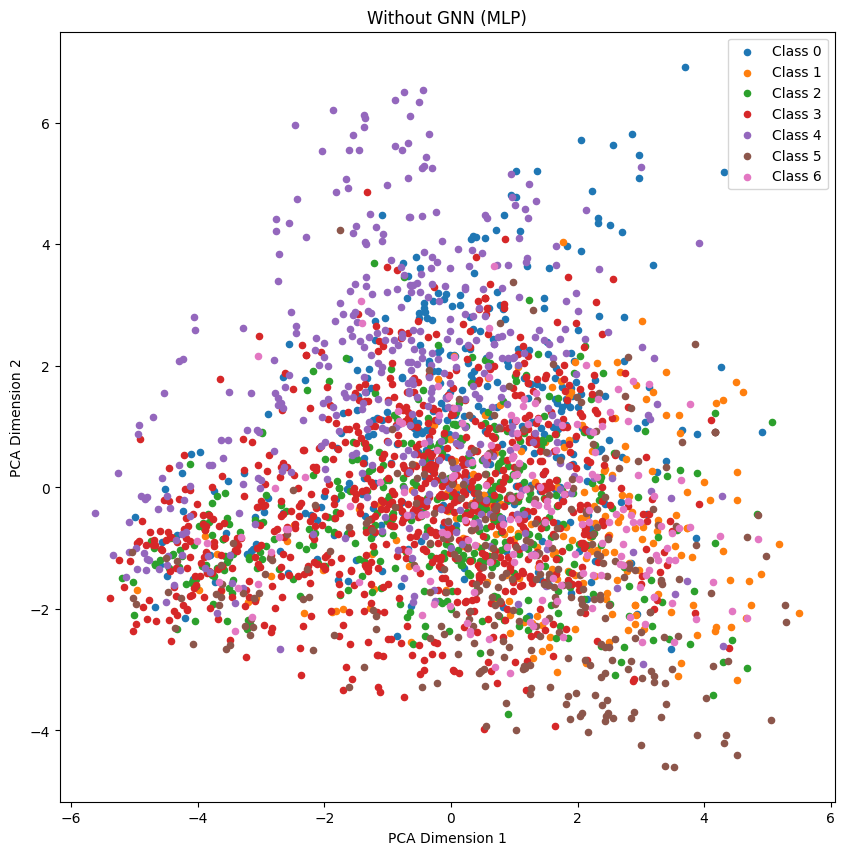

In [ ]:
plot_embeddings_separate(
    mlp_embeddings,
    "Without GNN (MLP)"
)

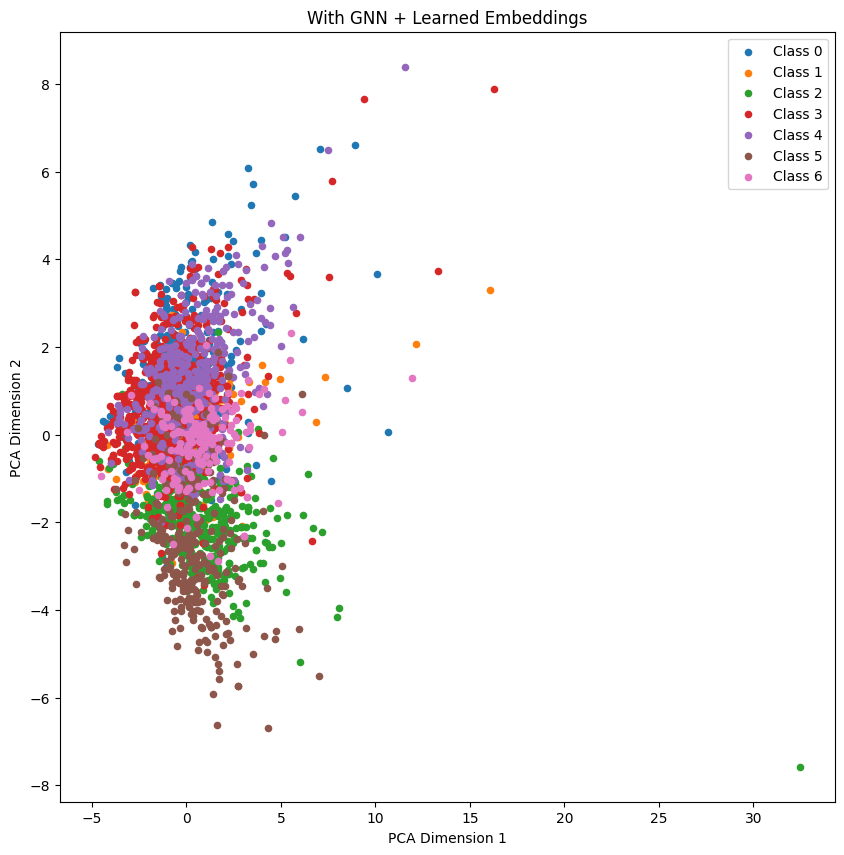

In [ ]:
plot_embeddings_separate(
    gcn_embeddings,
    "With GNN + Learned Embeddings"
)

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

In [ ]:
def plot_graph(vectors, labels, title):

    tsne = TSNE(n_components=2)

    reduced = tsne.fit_transform(vectors)

    plt.figure(figsize=(8,8))

    for class_id in range(dataset.num_classes):

        idx = labels == class_id

        plt.scatter(
            reduced[idx, 0],
            reduced[idx, 1],
            label=f"Class {class_id}",
            s=20
        )

    plt.legend()

    plt.title(title)

    plt.xlabel("PCA 1")

    plt.ylabel("PCA 2")

    plt.show()

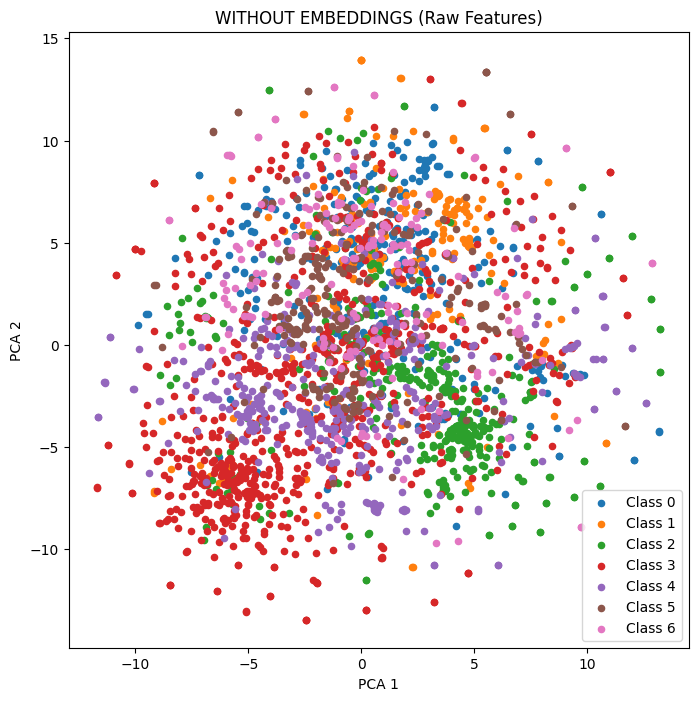

In [ ]:
raw_features = data.x.numpy()

labels = data.y.numpy()

plot_graph(
    raw_features,
    labels,
    "WITHOUT EMBEDDINGS (Raw Features)"
)

**Plot GCN EMBEDDINGS**

In [ ]:
gcn.eval()

out, embeddings = gcn(
    data.x,
    data.edge_index
)

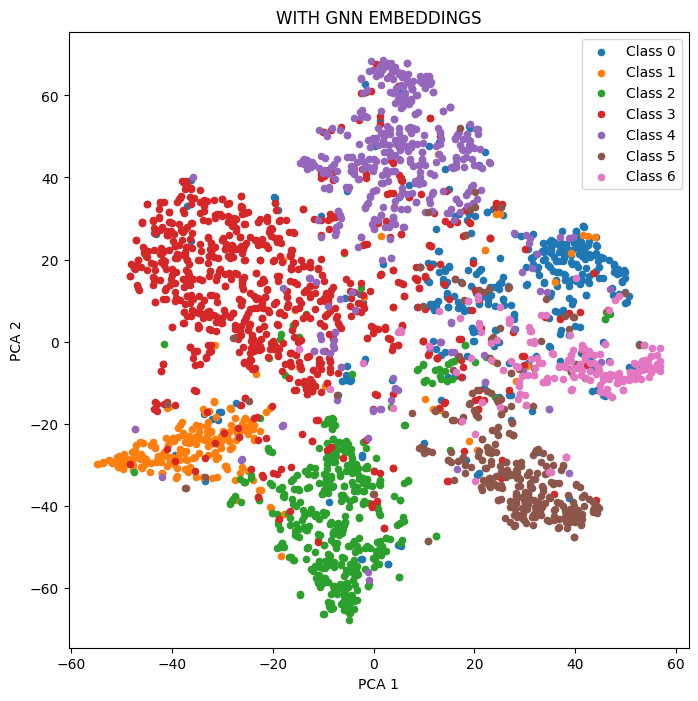

In [ ]:
plot_graph(
    embeddings.detach().numpy(),
    labels,
    "WITH GNN EMBEDDINGS"
)

| Without Embeddings     | With Embeddings            |
| ---------------------- | -------------------------- |
| Raw data               | Learned representation     |
| Sparse/noisy           | Dense/informative          |
| No semantic learning   | Semantic learning          |
| Weak structure         | Strong structure           |
| Original features only | Hidden intelligent vectors |


**1. WITHOUT EMBEDDINGS**

In [ ]:
class WithoutEmbedding(nn.Module):

    def __init__(self):

        super().__init__()

        self.linear = nn.Linear(
            dataset.num_features,
            dataset.num_classes
        )

    def forward(self, x):

        out = self.linear(x)

        return out

In [ ]:
model_no_emb = WithoutEmbedding()

In [ ]:
optimizer = torch.optim.Adam(
    model_no_emb.parameters(),
    lr=0.01
)

In [ ]:
for epoch in range(200):

    model_no_emb.train()

    optimizer.zero_grad()

    out = model_no_emb(data.x)

    loss = F.cross_entropy(
        out[data.train_mask],
        data.y[data.train_mask]
    )

    loss.backward()

    optimizer.step()

In [ ]:
model_no_emb.eval()

out = model_no_emb(data.x)

pred = out.argmax(dim=1)

correct = (
    pred[data.test_mask]
    ==
    data.y[data.test_mask]
).sum()

acc = int(correct) / int(data.test_mask.sum())

print("Without Embeddings Accuracy:", acc)

Without Embeddings Accuracy: 0.441


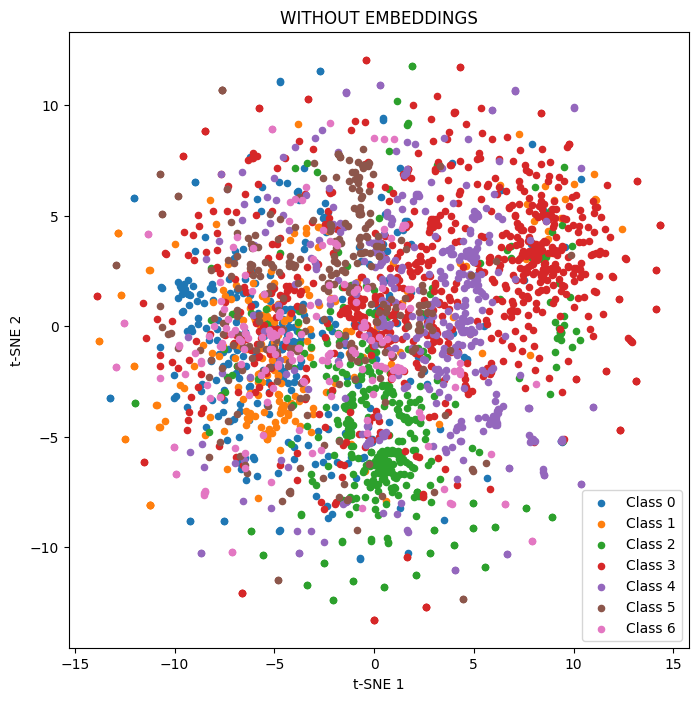

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# t-SNE object
tsne = TSNE(n_components=2)

# Convert raw features to 2D
raw_2d = tsne.fit_transform(
    data.x.numpy()
)

# Plot
plt.figure(figsize=(8,8))

for c in range(dataset.num_classes):

    idx = data.y.numpy() == c

    plt.scatter(
        raw_2d[idx,0],
        raw_2d[idx,1],
        label=f"Class {c}",
        s=20
    )

plt.legend()

plt.title("WITHOUT EMBEDDINGS")

plt.xlabel("t-SNE 1")

plt.ylabel("t-SNE 2")

plt.show()

**2. WITH EMBEDDINGS (GCN)**

In [ ]:
class WithEmbedding(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1 = GCNConv(
            dataset.num_features,
            16
        )

        self.conv2 = GCNConv(
            16,
            dataset.num_classes
        )

    def forward(self, x, edge_index):

        x = self.conv1(x, edge_index)

        embedding = x

        x = F.relu(x)

        out = self.conv2(x, edge_index)

        return out, embedding

In [ ]:
model_emb = WithEmbedding()

In [ ]:
optimizer = torch.optim.Adam(
    model_emb.parameters(),
    lr=0.01
)

In [ ]:
for epoch in range(200):

    model_emb.train()

    optimizer.zero_grad()

    out, embedding = model_emb(
        data.x,
        data.edge_index
    )

    loss = F.cross_entropy(
        out[data.train_mask],
        data.y[data.train_mask]
    )

    loss.backward()

    optimizer.step()

In [ ]:
model_emb.eval()

out, embeddings = model_emb(
    data.x,
    data.edge_index
)

pred = out.argmax(dim=1)

correct = (
    pred[data.test_mask]
    ==
    data.y[data.test_mask]
).sum()

acc = int(correct) / int(data.test_mask.sum())

print("With Embeddings Accuracy:", acc)

With Embeddings Accuracy: 0.774


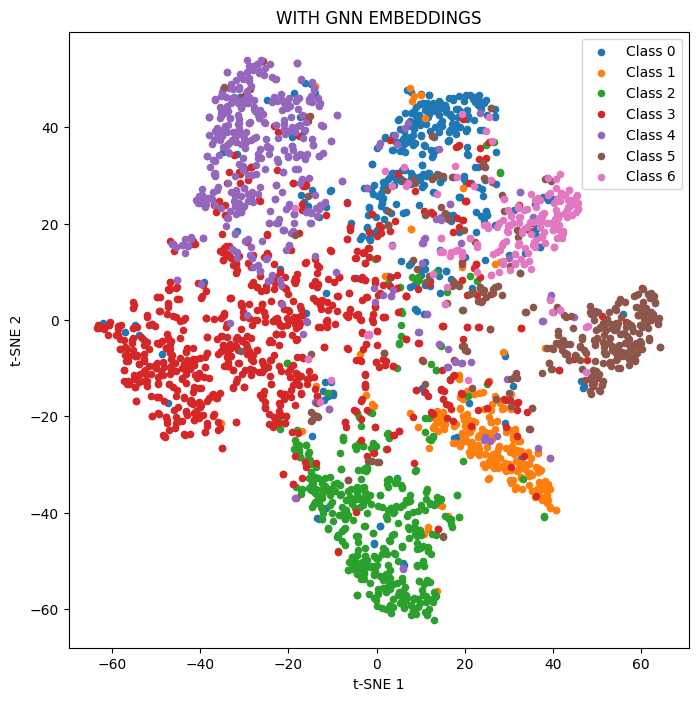

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# t-SNE object
tsne = TSNE(n_components=2)

# Convert embeddings to 2D
emb_2d = tsne.fit_transform(
    embeddings.detach().numpy()
)

# Plot
plt.figure(figsize=(8,8))

for c in range(dataset.num_classes):

    idx = data.y.numpy() == c

    plt.scatter(
        emb_2d[idx,0],
        emb_2d[idx,1],
        label=f"Class {c}",
        s=20
    )

plt.legend()

plt.title("WITH GNN EMBEDDINGS")

plt.xlabel("t-SNE 1")

plt.ylabel("t-SNE 2")

plt.show()

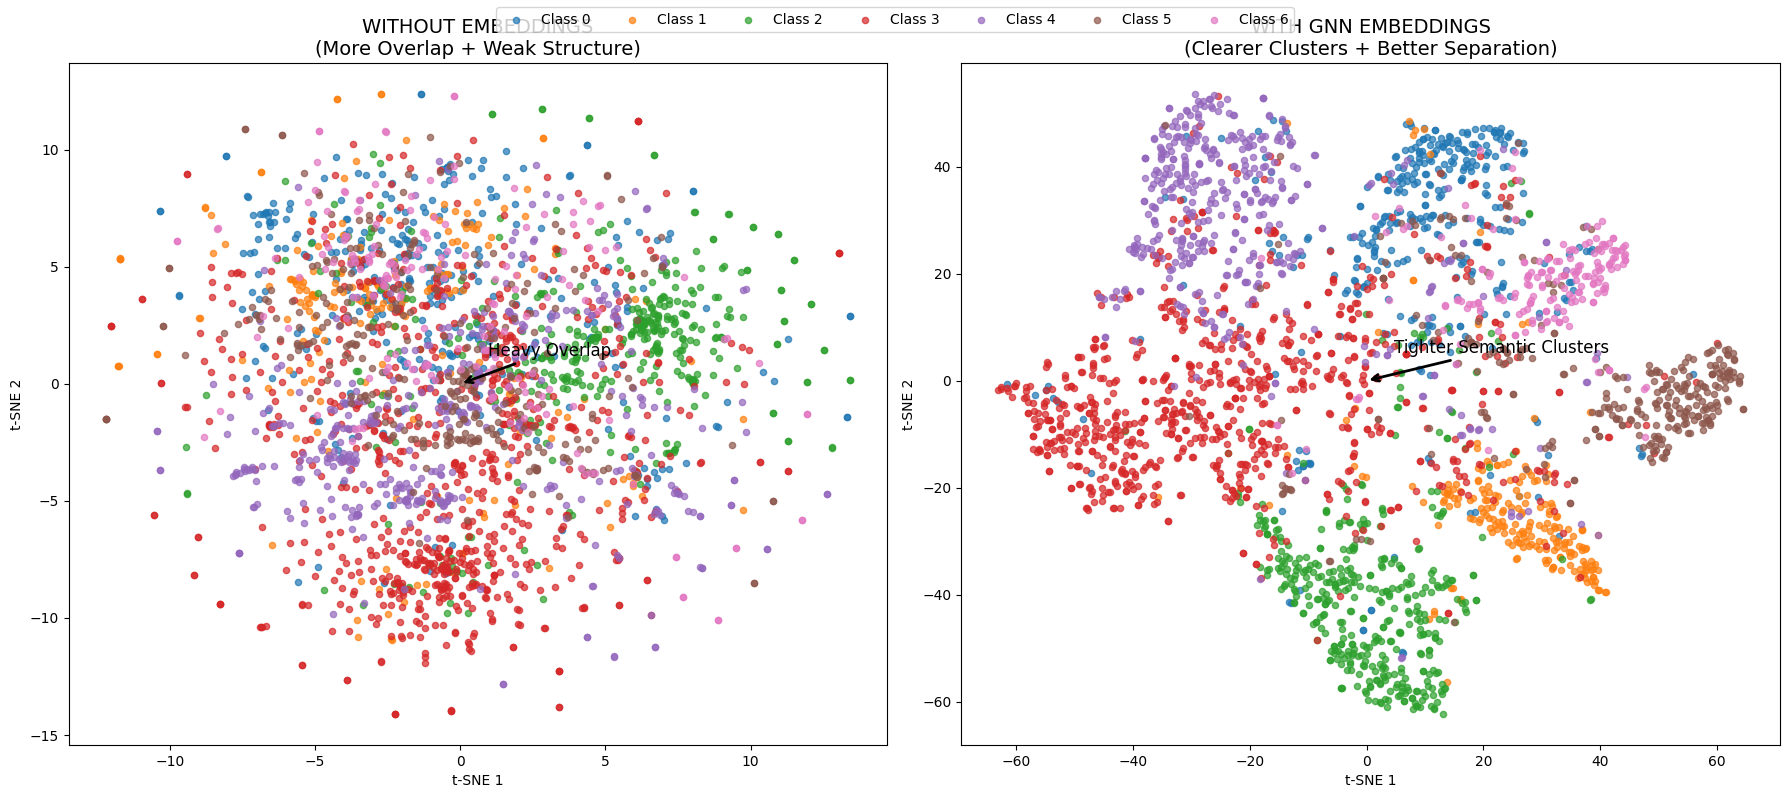

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# =====================================================
# 1. RAW FEATURES (WITHOUT EMBEDDINGS)
# =====================================================

tsne_raw = TSNE(n_components=2, random_state=42)

raw_2d = tsne_raw.fit_transform(
    data.x.numpy()
)

# =====================================================
# 2. GNN EMBEDDINGS
# =====================================================

model_emb.eval()

out, embeddings = model_emb(
    data.x,
    data.edge_index
)

tsne_emb = TSNE(n_components=2, random_state=42)

emb_2d = tsne_emb.fit_transform(
    embeddings.detach().numpy()
)

# =====================================================
# 3. SIDE-BY-SIDE PLOTS
# =====================================================

fig, axes = plt.subplots(1, 2, figsize=(18,8))

# -----------------------------------------------------
# LEFT GRAPH : WITHOUT EMBEDDINGS
# -----------------------------------------------------

for c in range(dataset.num_classes):

    idx = data.y.numpy() == c

    axes[0].scatter(
        raw_2d[idx,0],
        raw_2d[idx,1],
        label=f"Class {c}",
        s=20,
        alpha=0.7
    )

axes[0].set_title(
    "WITHOUT EMBEDDINGS\n(More Overlap + Weak Structure)",
    fontsize=14
)

axes[0].set_xlabel("t-SNE 1")
axes[0].set_ylabel("t-SNE 2")

# Mark overlap region
axes[0].annotate(
    "Heavy Overlap",
    xy=(0,0),
    xytext=(20,20),
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->', lw=2),
    fontsize=12,
    color='black'
)

# -----------------------------------------------------
# RIGHT GRAPH : WITH GNN EMBEDDINGS
# -----------------------------------------------------

for c in range(dataset.num_classes):

    idx = data.y.numpy() == c

    axes[1].scatter(
        emb_2d[idx,0],
        emb_2d[idx,1],
        label=f"Class {c}",
        s=20,
        alpha=0.7
    )

axes[1].set_title(
    "WITH GNN EMBEDDINGS\n(Clearer Clusters + Better Separation)",
    fontsize=14
)

axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")

# Mark cluster region
axes[1].annotate(
    "Tighter Semantic Clusters",
    xy=(0,0),
    xytext=(20,20),
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->', lw=2),
    fontsize=12,
    color='black'
)

# =====================================================
# COMMON LEGEND
# =====================================================

handles, labels = axes[1].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='upper center',
    ncol=7
)

plt.tight_layout()

plt.show()

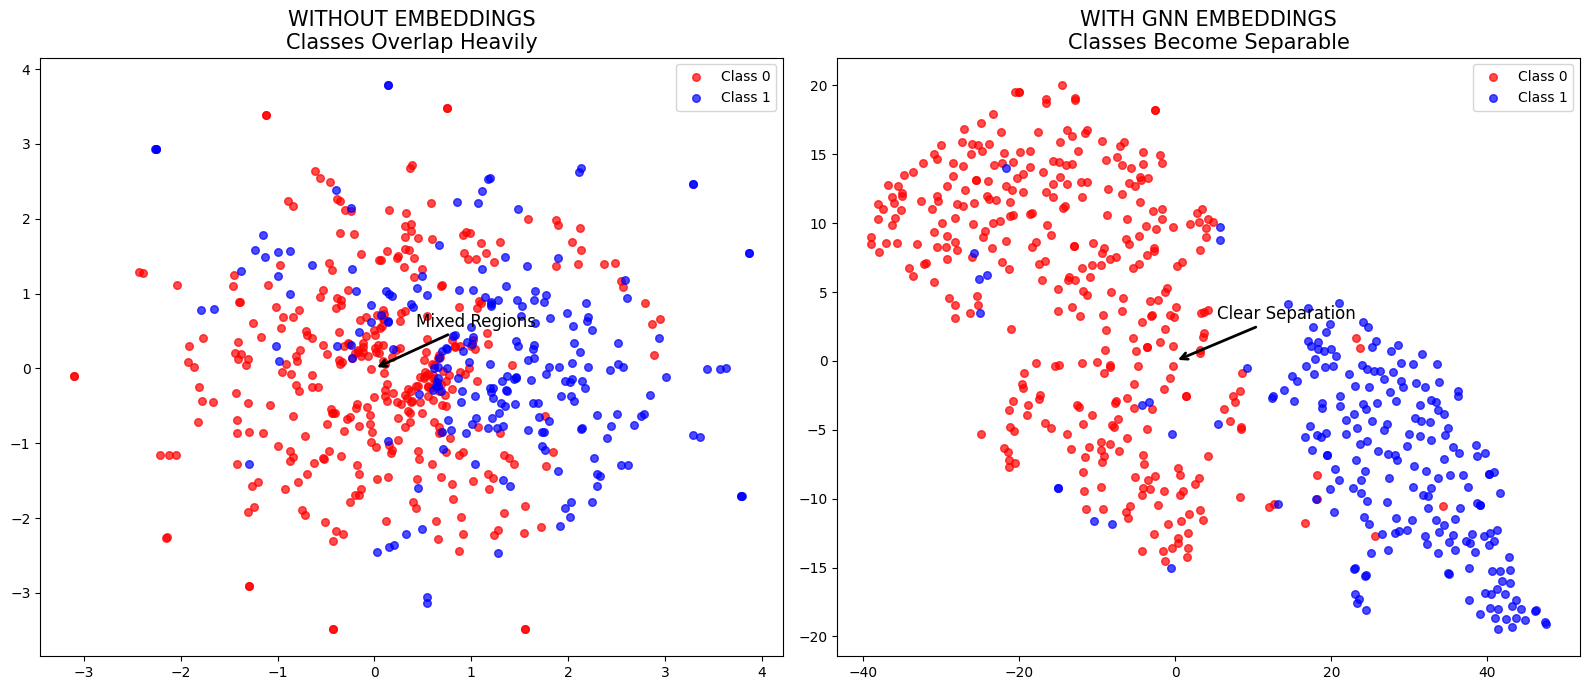

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# ============================================
# SELECT ONLY 2 CLASSES
# ============================================

selected_classes = [0, 1]

labels = data.y.numpy()

mask = np.isin(labels, selected_classes)

# ============================================
# RAW FEATURES
# ============================================

raw_features = data.x.numpy()[mask]

raw_labels = labels[mask]

tsne_raw = TSNE(
    n_components=2,
    random_state=42
)

raw_2d = tsne_raw.fit_transform(raw_features)

# ============================================
# GNN EMBEDDINGS
# ============================================

model_emb.eval()

out, embeddings = model_emb(
    data.x,
    data.edge_index
)

embeddings = embeddings.detach().numpy()[mask]

tsne_emb = TSNE(
    n_components=2,
    random_state=42
)

emb_2d = tsne_emb.fit_transform(embeddings)

# ============================================
# SIDE-BY-SIDE PLOTS
# ============================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16,7)
)

colors = ['red', 'blue']

# ============================================
# WITHOUT EMBEDDINGS
# ============================================

for i, c in enumerate(selected_classes):

    idx = raw_labels == c

    axes[0].scatter(
        raw_2d[idx,0],
        raw_2d[idx,1],
        color=colors[i],
        label=f'Class {c}',
        s=30,
        alpha=0.7
    )

axes[0].set_title(
    "WITHOUT EMBEDDINGS\nClasses Overlap Heavily",
    fontsize=15
)

axes[0].legend()

axes[0].annotate(
    "Mixed Regions",
    xy=(0,0),
    xytext=(30,30),
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->', lw=2),
    fontsize=12
)

# ============================================
# WITH GNN EMBEDDINGS
# ============================================

for i, c in enumerate(selected_classes):

    idx = raw_labels == c

    axes[1].scatter(
        emb_2d[idx,0],
        emb_2d[idx,1],
        color=colors[i],
        label=f'Class {c}',
        s=30,
        alpha=0.7
    )

axes[1].set_title(
    "WITH GNN EMBEDDINGS\nClasses Become Separable",
    fontsize=15
)

axes[1].legend()

axes[1].annotate(
    "Clear Separation",
    xy=(0,0),
    xytext=(30,30),
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->', lw=2),
    fontsize=12
)

plt.tight_layout()

plt.show()

**Time Calculation**

In [ ]:
import time

**WITHOUT EMBEDDINGS**

In [ ]:
start_time = time.time()

In [ ]:
model_no_emb = WithoutEmbedding()

optimizer = torch.optim.Adam(
    model_no_emb.parameters(),
    lr=0.01
)

for epoch in range(200):

    model_no_emb.train()

    optimizer.zero_grad()

    out = model_no_emb(data.x)

    loss = F.cross_entropy(
        out[data.train_mask],
        data.y[data.train_mask]
    )

    loss.backward()

    optimizer.step()

In [ ]:
end_time = time.time()

training_time_no_emb = end_time - start_time

print("WITHOUT EMBEDDINGS Training Time:")
print(training_time_no_emb)

WITHOUT EMBEDDINGS Training Time:
12.08160924911499


In [ ]:
start_time = time.time()

model_no_emb.eval()

out = model_no_emb(data.x)

end_time = time.time()

inference_time_no_emb = end_time - start_time

print("WITHOUT EMBEDDINGS Inference Time:")
print(inference_time_no_emb)

WITHOUT EMBEDDINGS Inference Time:
0.006816864013671875


In [ ]:
params_no_emb = sum(
    p.numel()
    for p in model_no_emb.parameters()
)

print("WITHOUT EMBEDDINGS Parameters:")
print(params_no_emb)

WITHOUT EMBEDDINGS Parameters:
10038


In [ ]:
pred = out.argmax(dim=1)

correct = (
    pred[data.test_mask]
    ==
    data.y[data.test_mask]
).sum()

acc_no_emb = int(correct) / int(data.test_mask.sum())

print("WITHOUT EMBEDDINGS Accuracy:")
print(acc_no_emb)

WITHOUT EMBEDDINGS Accuracy:
0.445


**WITH GNN EMBEDDINGS**

In [ ]:
start_time = time.time()

In [ ]:
model_emb = WithEmbedding()

optimizer = torch.optim.Adam(
    model_emb.parameters(),
    lr=0.01
)

for epoch in range(200):

    model_emb.train()

    optimizer.zero_grad()

    out, embeddings = model_emb(
        data.x,
        data.edge_index
    )

    loss = F.cross_entropy(
        out[data.train_mask],
        data.y[data.train_mask]
    )

    loss.backward()

    optimizer.step()

In [ ]:
end_time = time.time()

training_time_emb = end_time - start_time

print("WITH EMBEDDINGS Training Time:")
print(training_time_emb)

WITH EMBEDDINGS Training Time:
10.673198699951172


In [ ]:
start_time = time.time()

model_emb.eval()

out, embeddings = model_emb(
    data.x,
    data.edge_index
)

end_time = time.time()

inference_time_emb = end_time - start_time

print("WITH EMBEDDINGS Inference Time:")
print(inference_time_emb)

WITH EMBEDDINGS Inference Time:
0.017022132873535156


In [ ]:
params_emb = sum(
    p.numel()
    for p in model_emb.parameters()
)

print("WITH EMBEDDINGS Parameters:")
print(params_emb)

WITH EMBEDDINGS Parameters:
23063


In [ ]:
pred = out.argmax(dim=1)

correct = (
    pred[data.test_mask]
    ==
    data.y[data.test_mask]
).sum()

acc_emb = int(correct) / int(data.test_mask.sum())

print("WITH EMBEDDINGS Accuracy:")
print(acc_emb)

WITH EMBEDDINGS Accuracy:
0.777


| Without Embeddings              | With GNN Embeddings                         |
| ------------------------------- | ------------------------------------------- |
| Uses original features directly | Learns graph-aware semantic representations |


In [ ]:
print("\n========== FINAL COMPARISON ==========\n")

print(f"Without Embeddings Accuracy : {acc_no_emb:.4f}")
print(f"With GNN Embeddings Accuracy : {acc_emb:.4f}")

print()

print(f"Without Embeddings Training Time : {training_time_no_emb:.4f} sec")
print(f"With GNN Embeddings Training Time : {training_time_emb:.4f} sec")

print()

print(f"Without Embeddings Inference Time : {inference_time_no_emb:.6f} sec")
print(f"With GNN Embeddings Inference Time : {inference_time_emb:.6f} sec")

print()

print(f"Without Embeddings Parameters : {params_no_emb}")
print(f"With GNN Embeddings Parameters : {params_emb}")


========== FINAL COMPARISON ==========

Without Embeddings Accuracy : 0.4450
With GNN Embeddings Accuracy : 0.7770

Without Embeddings Training Time : 12.0816 sec
With GNN Embeddings Training Time : 10.6732 sec

Without Embeddings Inference Time : 0.006817 sec
With GNN Embeddings Inference Time : 0.017022 sec

Without Embeddings Parameters : 10038
With GNN Embeddings Parameters : 23063


| Key Aspect           | Without Embeddings       | With GNN Embeddings                                |
| -------------------- | ------------------------ | -------------------------------------------------- |
| Input Used           | Raw node features only   | Node features + graph structure                    |
| Neighbor Information | ❌ Not used               | ✅ Used                                             |
| Graph Awareness      | ❌ No                     | ✅ Yes                                              |
| Representation Type  | Original sparse vectors  | Learned dense vectors                              |
| Learning Capability  | Limited                  | Strong semantic learning                           |
| Class Separation     | Weak                     | Better clustering                                  |
| Visualization        | Mixed/overlapping points | Clearer semantic clusters                          |
| Message Passing      | ❌ No                     | ✅ Yes                                              |
| Runtime              | Faster                   | Slower                                             |
| Memory Usage         | Lower                    | Higher                                             |
| Scalability          | Easier                   | Harder                                             |
| Accuracy             | Usually lower            | Usually higher                                     |
| Real Understanding   | "I know only myself"     | "I learn from neighbors"                           |
| Best For             | Simple/non-graph data    | Relational/graph problems                          |
| Real Examples        | Basic ML classifiers     | Social networks, recommendation systems, molecules |


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt

from sklearn.manifold import TSNE

from torch_geometric.datasets import Planetoid

from torch_geometric.nn import (
    GCNConv,
    GATConv,
    GINConv
)

**1. GCN IMPLEMENTATION**

In [ ]:
class GCN(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1 = GCNConv(
            dataset.num_features,
            16
        )

        self.conv2 = GCNConv(
            16,
            dataset.num_classes
        )

    def forward(self, x, edge_index):

        x = self.conv1(x, edge_index)

        embedding = x

        x = F.relu(x)

        x = self.conv2(x, edge_index)

        return x, embedding

**2. GAT IMPLEMENTATION**

In [ ]:
class GAT(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1 = GATConv(
            dataset.num_features,
            8,
            heads=8
        )

        self.conv2 = GATConv(
            8 * 8,
            dataset.num_classes,
            heads=1
        )

    def forward(self, x, edge_index):

        x = self.conv1(x, edge_index)

        embedding = x

        x = F.elu(x)

        x = self.conv2(x, edge_index)

        return x, embedding

**3. GIN IMPLEMENTATION**

In [ ]:
class GIN(nn.Module):

    def __init__(self):

        super().__init__()

        nn1 = nn.Sequential(
            nn.Linear(dataset.num_features, 16),
            nn.ReLU(),
            nn.Linear(16, 16)
        )

        nn2 = nn.Sequential(
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, dataset.num_classes)
        )

        self.conv1 = GINConv(nn1)

        self.conv2 = GINConv(nn2)

    def forward(self, x, edge_index):

        x = self.conv1(x, edge_index)

        embedding = x

        x = F.relu(x)

        x = self.conv2(x, edge_index)

        return x, embedding

**COMMON TRAINING FUNCTION**

In [ ]:
def train_model(model):

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.01
    )

    for epoch in range(200):

        model.train()

        optimizer.zero_grad()

        out, emb = model(
            data.x,
            data.edge_index
        )

        loss = F.cross_entropy(
            out[data.train_mask],
            data.y[data.train_mask]
        )

        loss.backward()

        optimizer.step()

    return model

In [ ]:
def test_model(model):

    model.eval()

    out, emb = model(
        data.x,
        data.edge_index
    )

    pred = out.argmax(dim=1)

    correct = (
        pred[data.test_mask]
        ==
        data.y[data.test_mask]
    ).sum()

    acc = int(correct) / int(data.test_mask.sum())

    print("Accuracy:", acc)

    return emb

**TRAIN ALL MODELS**

In [ ]:
gcn = GCN()

train_model(gcn)

gcn_emb = test_model(gcn)

Accuracy: 0.78


In [ ]:
gat = GAT()

train_model(gat)

gat_emb = test_model(gat)

Accuracy: 0.762


In [ ]:
gin = GIN()

train_model(gin)

gin_emb = test_model(gin)

Accuracy: 0.687


**VISUALIZE EMBEDDINGS**

In [ ]:
def visualize(embeddings, title):

    tsne = TSNE(n_components=2)

    reduced = tsne.fit_transform(
        embeddings.detach().numpy()
    )

    labels = data.y.numpy()

    plt.figure(figsize=(8,8))

    for c in range(dataset.num_classes):

        idx = labels == c

        plt.scatter(
            reduced[idx,0],
            reduced[idx,1],
            label=f'Class {c}',
            s=20
        )

    plt.legend()

    plt.title(title)

    plt.xlabel("t-SNE 1")

    plt.ylabel("t-SNE 2")

    plt.show()

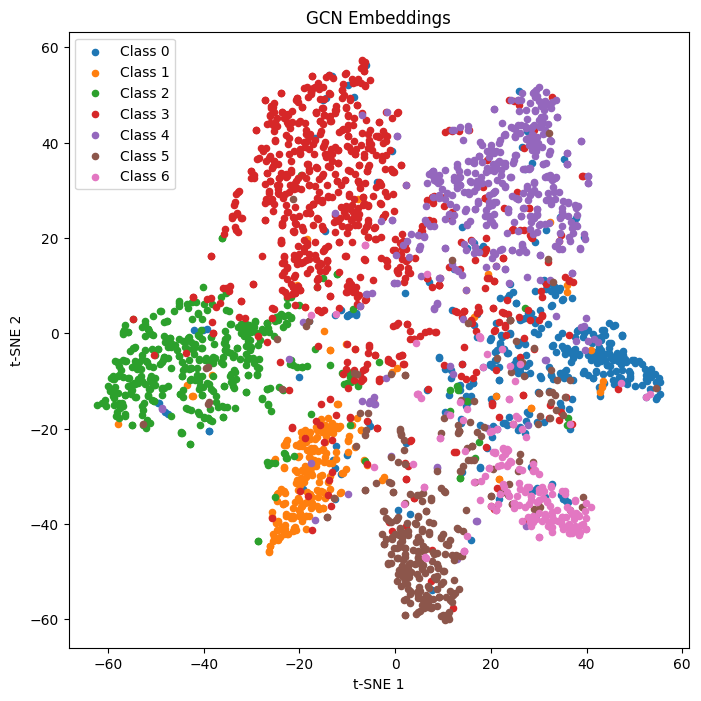

In [ ]:
visualize(
    gcn_emb,
    "GCN Embeddings"
)

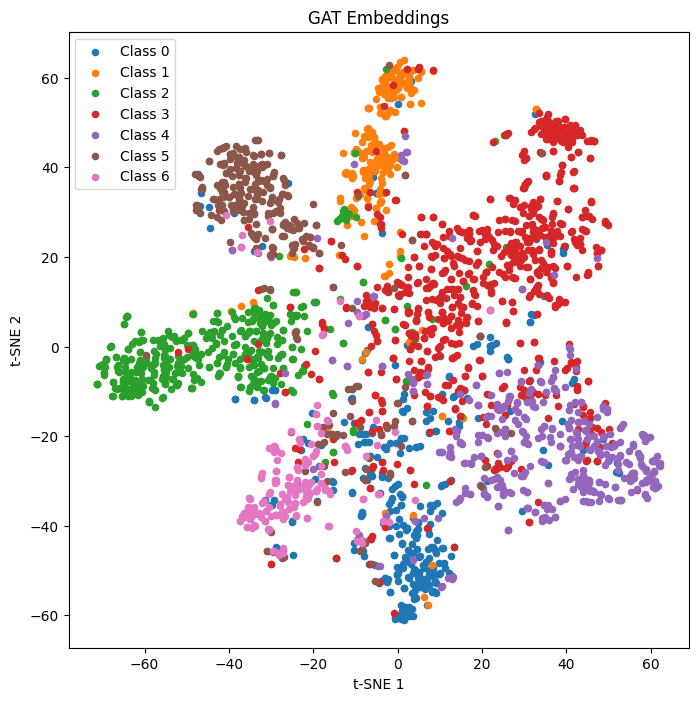

In [ ]:
visualize(
    gat_emb,
    "GAT Embeddings"
)

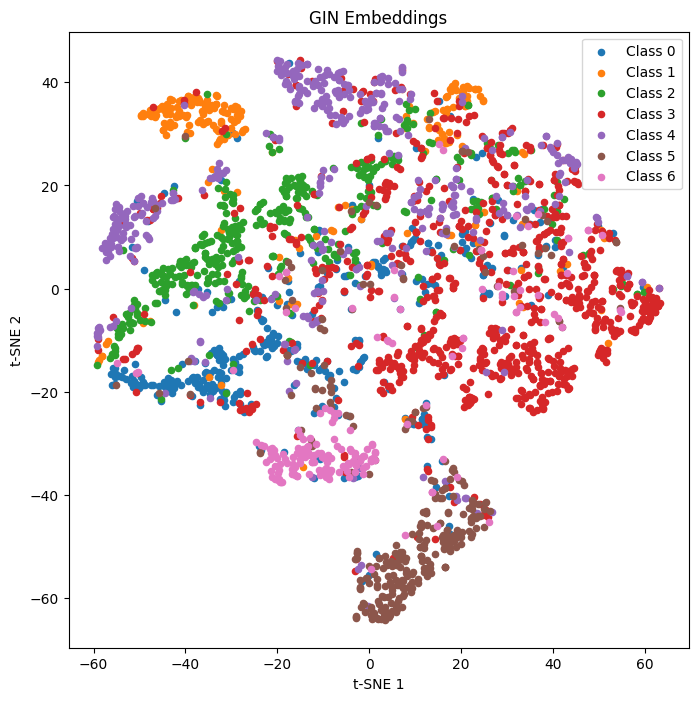

In [ ]:
visualize(
    gin_emb,
    "GIN Embeddings"
)

| Model | Embedding Shape             |
| ----- | --------------------------- |
| GCN   | smooth clusters             |
| GAT   | sharper clusters            |
| GIN   | structurally dense clusters |


| Property                           | Only Node2Vec              | Node2Vec + Features / GCN  |
| ---------------------------------- | -------------------------- | -------------------------- |
| Uses graph structure               | ✅                          | ✅                          |
| Uses node features (`data.x`)      | ❌                          | ✅                          |
| Uses random walks                  | ✅                          | ✅                          |
| Learns embeddings                  | ✅                          | ✅                          |
| Message passing                    | ❌                          | ✅ (if GCN used)            |
| Embeddings type                    | structural                 | structural + semantic      |
| Training style                     | unsupervised               | supervised/semi-supervised |
| Embeddings updated during training | ❌ static                   | ✅ dynamic                  |
| Captures node content              | ❌                          | ✅                          |
| Captures topology                  | ✅                          | ✅                          |
| Classification quality             | moderate                   | usually better             |
| Complexity                         | simpler                    | more complex               |
| Best use case                      | no node features available | graph + features available |


In [ ]:
class GCN(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1 = GCNConv(
            dataset.num_features,
            16
        )

        self.conv2 = GCNConv(
            16,
            dataset.num_classes
        )

    def forward(self, x, edge_index):

        x = self.conv1(x, edge_index)

        embedding = x

        x = F.relu(x)

        x = self.conv2(x, edge_index)

        return x, embedding

In [ ]:
class GAT(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1 = GATConv(
            dataset.num_features,
            8,
            heads=8
        )

        self.conv2 = GATConv(
            8*8,
            dataset.num_classes,
            heads=1
        )

    def forward(self, x, edge_index):

        x = self.conv1(x, edge_index)

        embedding = x

        x = F.elu(x)

        x = self.conv2(x, edge_index)

        return x, embedding

In [ ]:
class GIN(nn.Module):

    def __init__(self):

        super().__init__()

        nn1 = nn.Sequential(
            nn.Linear(dataset.num_features,16),
            nn.ReLU(),
            nn.Linear(16,16)
        )

        nn2 = nn.Sequential(
            nn.Linear(16,16),
            nn.ReLU(),
            nn.Linear(16,dataset.num_classes)
        )

        self.conv1 = GINConv(nn1)

        self.conv2 = GINConv(nn2)

    def forward(self, x, edge_index):

        x = self.conv1(x, edge_index)

        embedding = x

        x = F.relu(x)

        x = self.conv2(x, edge_index)

        return x, embedding

In [ ]:
def train_model(model):

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.01
    )

    for epoch in range(200):

        model.train()

        optimizer.zero_grad()

        out, emb = model(
            data.x,
            data.edge_index
        )

        loss = F.cross_entropy(
            out[data.train_mask],
            data.y[data.train_mask]
        )

        loss.backward()

        optimizer.step()

    return model

In [ ]:
def visualize_embeddings(
    model,
    title
):

    model.eval()

    out, emb = model(
        data.x,
        data.edge_index
    )

    emb = emb.detach().numpy()

    tsne = TSNE(
        n_components=2,
        random_state=42
    )

    reduced = tsne.fit_transform(emb)

    labels = data.y.numpy()

    plt.figure(figsize=(8,8))

    for c in range(dataset.num_classes):

        idx = labels == c

        plt.scatter(
            reduced[idx,0],
            reduced[idx,1],
            label=f'Class {c}',
            s=20
        )

    plt.legend()

    plt.title(title)

    plt.xlabel("t-SNE 1")

    plt.ylabel("t-SNE 2")

    plt.show()

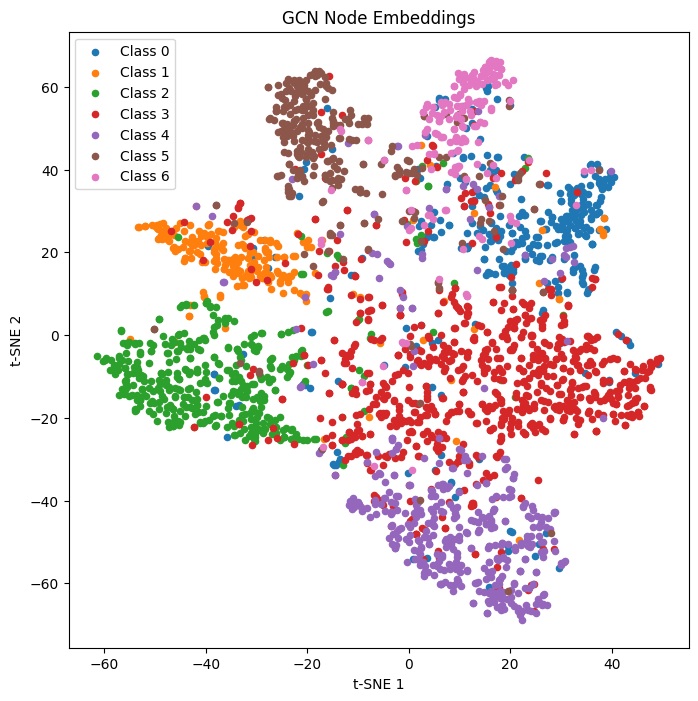

In [ ]:
gcn = GCN()

train_model(gcn)

visualize_embeddings(
    gcn,
    "GCN Node Embeddings"
)

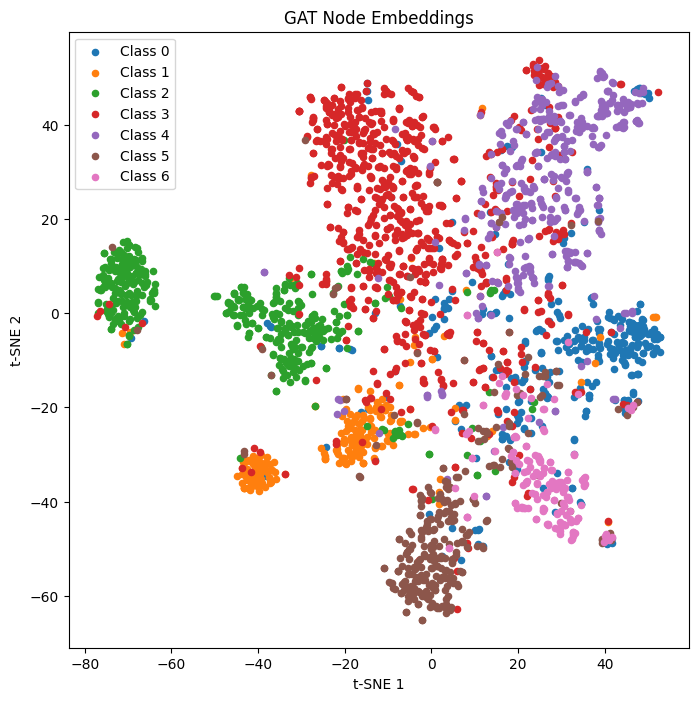

In [ ]:
gat = GAT()

train_model(gat)

visualize_embeddings(
    gat,
    "GAT Node Embeddings"
)

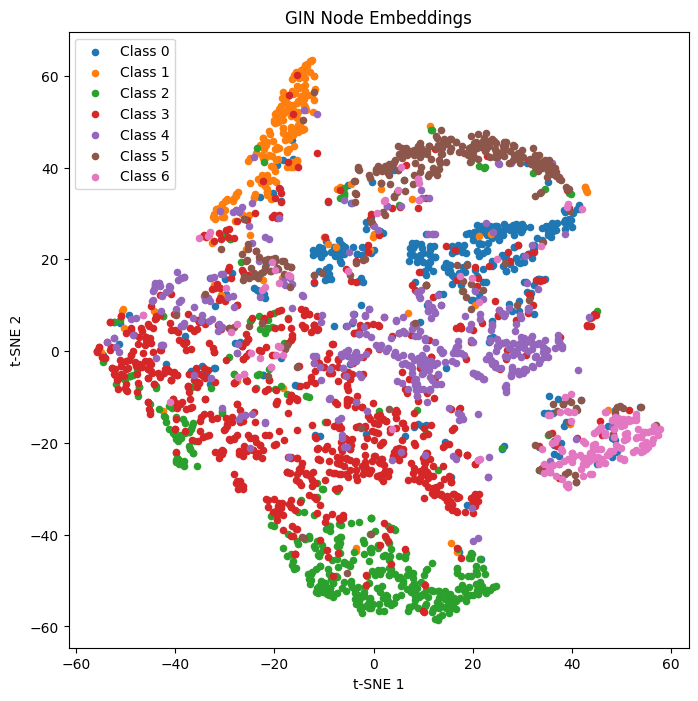

In [ ]:
gin = GIN()

train_model(gin)

visualize_embeddings(
    gin,
    "GIN Node Embeddings"
)

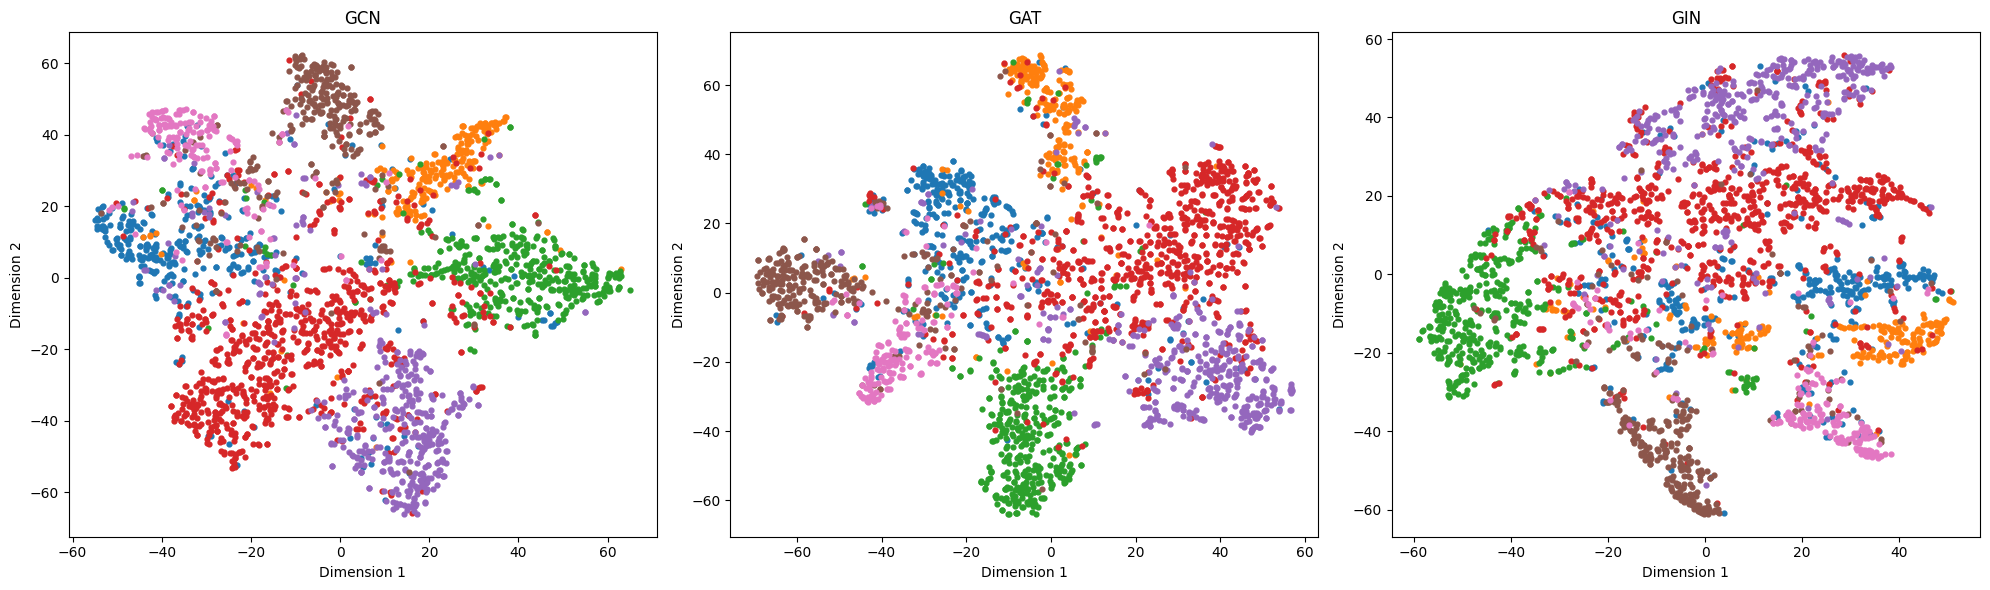

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt

from sklearn.manifold import TSNE

from torch_geometric.datasets import Planetoid

from torch_geometric.nn import (
    GCNConv,
    GATConv,
    GINConv
)

# ==================================================
# LOAD DATASET
# ==================================================

dataset = Planetoid(
    root='data/Cora',
    name='Cora'
)

data = dataset[0]

# ==================================================
# GCN
# ==================================================

class GCN(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1 = GCNConv(
            dataset.num_features,
            16
        )

        self.conv2 = GCNConv(
            16,
            dataset.num_classes
        )

    def forward(self, x, edge_index):

        x = self.conv1(x, edge_index)

        embedding = x

        x = F.relu(x)

        x = self.conv2(x, edge_index)

        return x, embedding

# ==================================================
# GAT
# ==================================================

class GAT(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1 = GATConv(
            dataset.num_features,
            8,
            heads=8
        )

        self.conv2 = GATConv(
            8*8,
            dataset.num_classes,
            heads=1
        )

    def forward(self, x, edge_index):

        x = self.conv1(x, edge_index)

        embedding = x

        x = F.elu(x)

        x = self.conv2(x, edge_index)

        return x, embedding

# ==================================================
# GIN
# ==================================================

class GIN(nn.Module):

    def __init__(self):

        super().__init__()

        nn1 = nn.Sequential(
            nn.Linear(dataset.num_features,16),
            nn.ReLU(),
            nn.Linear(16,16)
        )

        nn2 = nn.Sequential(
            nn.Linear(16,16),
            nn.ReLU(),
            nn.Linear(16,dataset.num_classes)
        )

        self.conv1 = GINConv(nn1)

        self.conv2 = GINConv(nn2)

    def forward(self, x, edge_index):

        x = self.conv1(x, edge_index)

        embedding = x

        x = F.relu(x)

        x = self.conv2(x, edge_index)

        return x, embedding

# ==================================================
# TRAIN FUNCTION
# ==================================================

def train_model(model):

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.01
    )

    for epoch in range(200):

        model.train()

        optimizer.zero_grad()

        out, emb = model(
            data.x,
            data.edge_index
        )

        loss = F.cross_entropy(
            out[data.train_mask],
            data.y[data.train_mask]
        )

        loss.backward()

        optimizer.step()

    return model

# ==================================================
# GET EMBEDDINGS
# ==================================================

def get_embeddings(model):

    model.eval()

    out, emb = model(
        data.x,
        data.edge_index
    )

    return emb.detach().numpy()

# ==================================================
# TRAIN MODELS
# ==================================================

gcn = GCN()
gat = GAT()
gin = GIN()

train_model(gcn)
train_model(gat)
train_model(gin)

# ==================================================
# GET EMBEDDINGS
# ==================================================

gcn_emb = get_embeddings(gcn)
gat_emb = get_embeddings(gat)
gin_emb = get_embeddings(gin)

# ==================================================
# t-SNE REDUCTION
# ==================================================

tsne = TSNE(
    n_components=2,
    random_state=42
)

gcn_2d = tsne.fit_transform(gcn_emb)

gat_2d = tsne.fit_transform(gat_emb)

gin_2d = tsne.fit_transform(gin_emb)

labels = data.y.numpy()

# ==================================================
# SINGLE REPRESENTATION
# ==================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(20,6)
)

models = [
    ("GCN", gcn_2d),
    ("GAT", gat_2d),
    ("GIN", gin_2d)
]

for ax, (name, emb) in zip(axes, models):

    for c in range(dataset.num_classes):

        idx = labels == c

        ax.scatter(
            emb[idx,0],
            emb[idx,1],
            label=f'Class {c}',
            s=12
        )

    ax.set_title(name)

    ax.set_xlabel("Dimension 1")

    ax.set_ylabel("Dimension 2")

plt.tight_layout()

plt.show()